In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor


In [2]:
df =pd.read_csv("student_habits_performance.csv")
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [4]:
sns.set(style="whitegrid")

In [5]:
df.isna().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [6]:
df =df.dropna()
df.duplicated().sum()
import warnings
warnings.filterwarnings("ignore")
df.describe(include="object").columns


Index(['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation'],
      dtype='object')

In [7]:
categorical_col=['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation']
for col in categorical_col:
  print(f"Value counts for {col}: \n {df[col].value_counts()}")

Value counts for student_id: 
 student_id
S1000    1
S1001    1
S1002    1
S1003    1
S1004    1
        ..
S1995    1
S1996    1
S1997    1
S1998    1
S1999    1
Name: count, Length: 909, dtype: int64
Value counts for gender: 
 gender
Male      440
Female    433
Other      36
Name: count, dtype: int64
Value counts for part_time_job: 
 part_time_job
No     713
Yes    196
Name: count, dtype: int64
Value counts for diet_quality: 
 diet_quality
Fair    396
Good    347
Poor    166
Name: count, dtype: int64
Value counts for parental_education_level: 
 parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
Value counts for internet_quality: 
 internet_quality
Good       410
Average    352
Poor       147
Name: count, dtype: int64
Value counts for extracurricular_participation: 
 extracurricular_participation
No     620
Yes    289
Name: count, dtype: int64


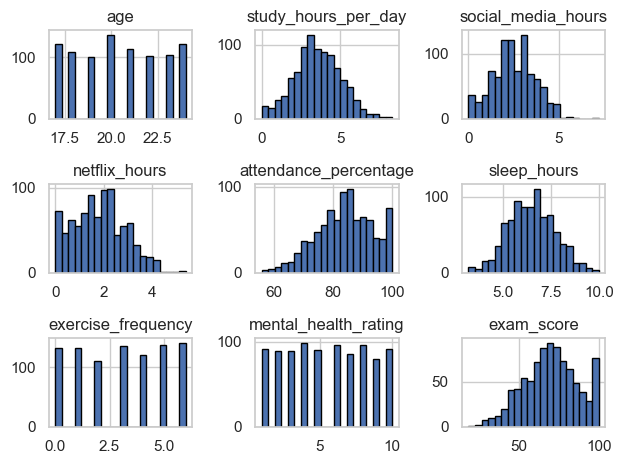

In [8]:
df.hist(bins=20,edgecolor='black')
plt.tight_layout()
plt.show()

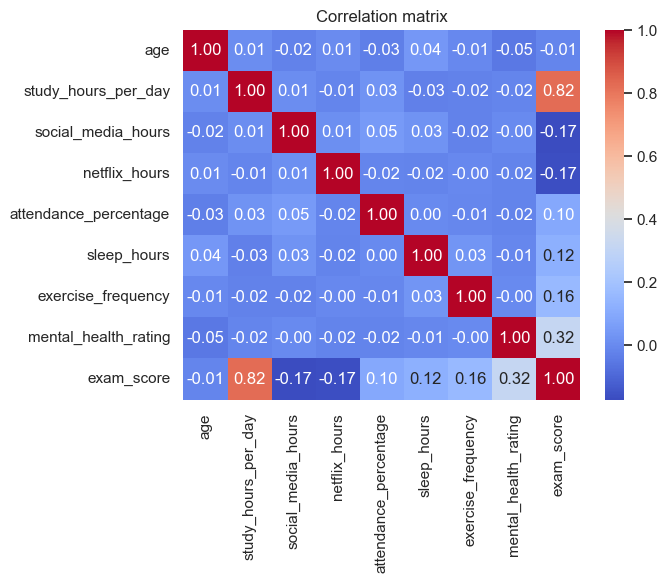

In [9]:
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm",annot=True,fmt='.2f')
plt.title("Correlation matrix")
plt.show()

In [10]:
df.describe().columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

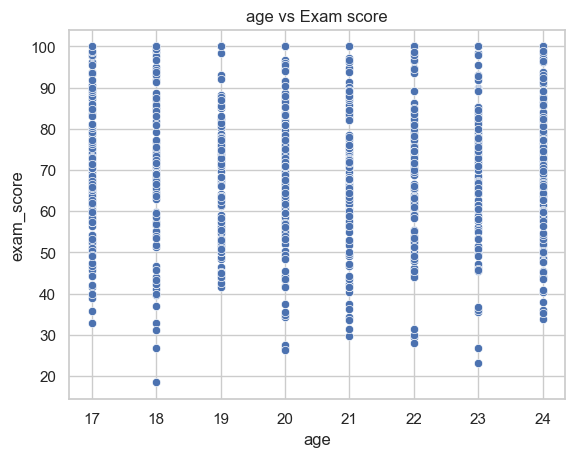

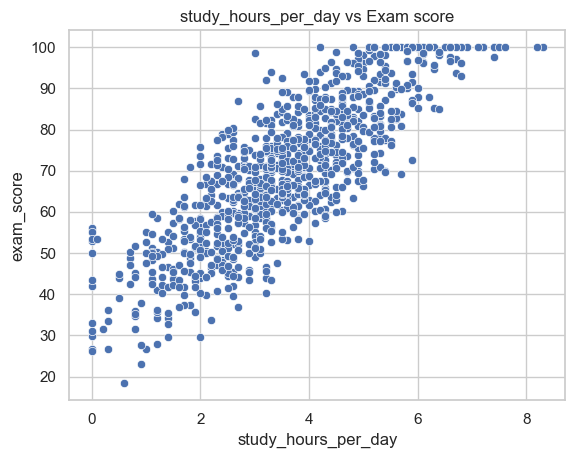

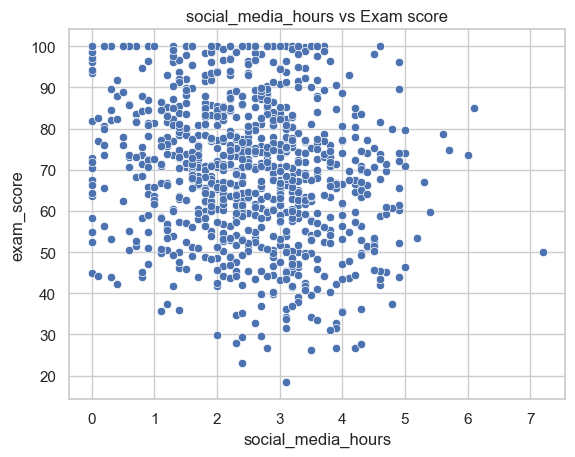

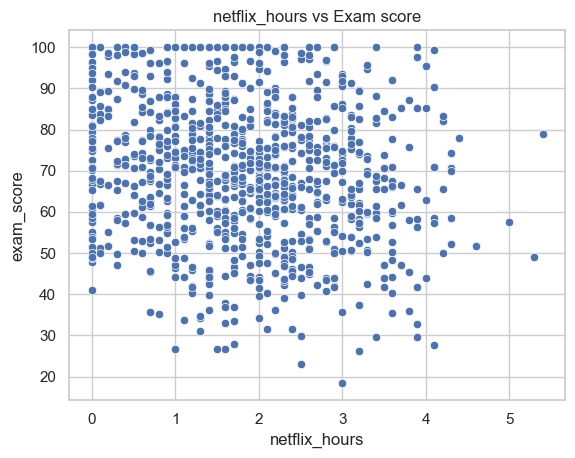

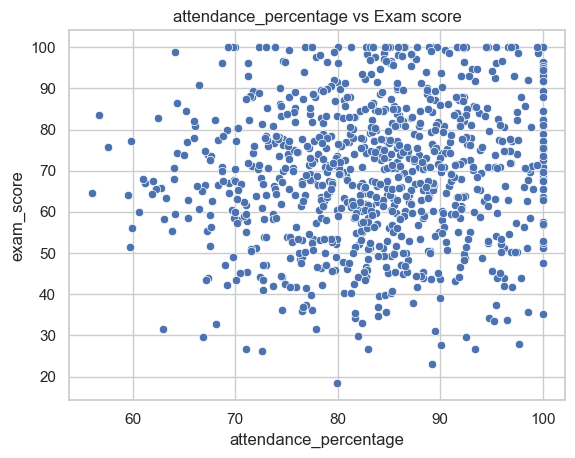

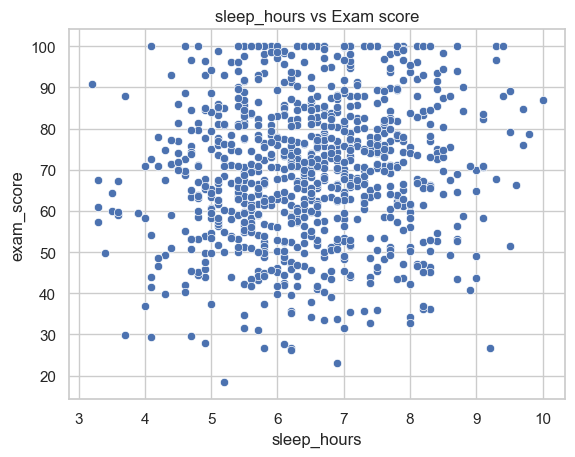

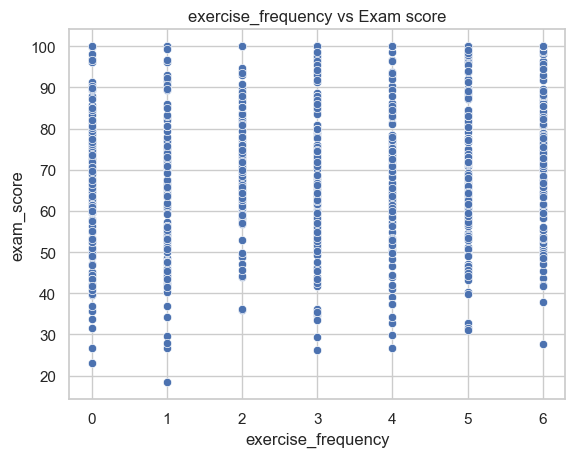

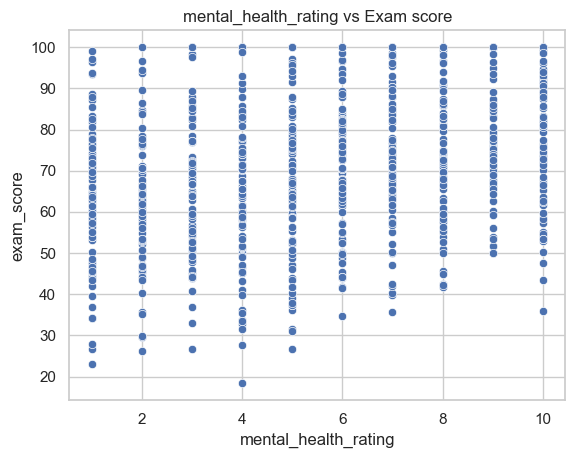

In [11]:
num_features = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', ]
for feature in num_features:
  sns.scatterplot(data=df,x=feature,y="exam_score")
  plt.title(f"{feature} vs Exam score")
  plt.show()

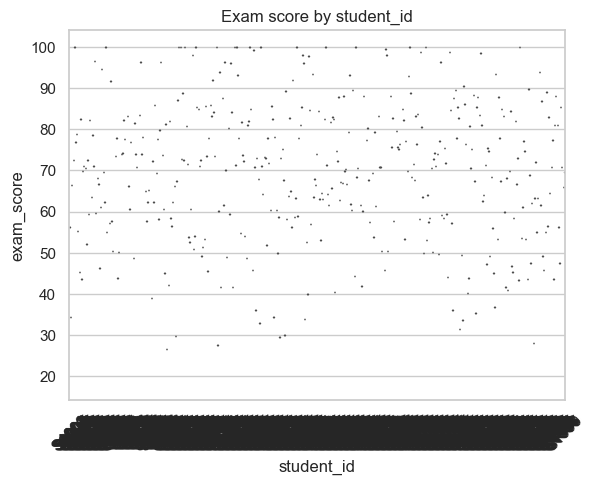

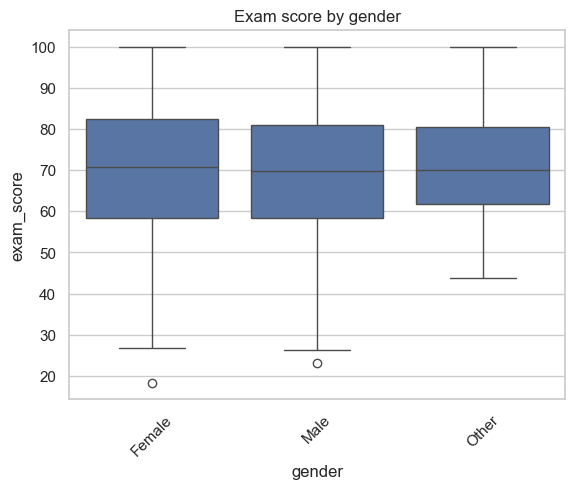

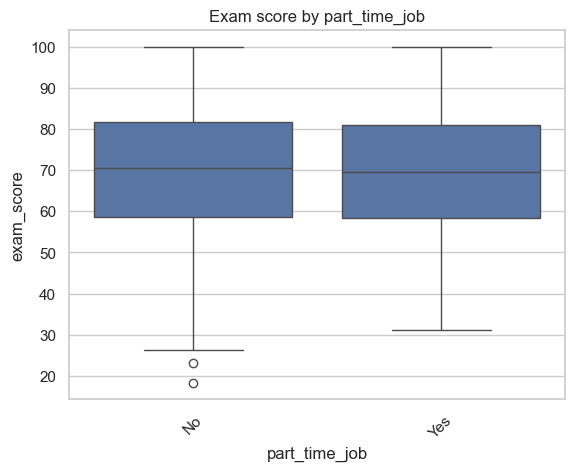

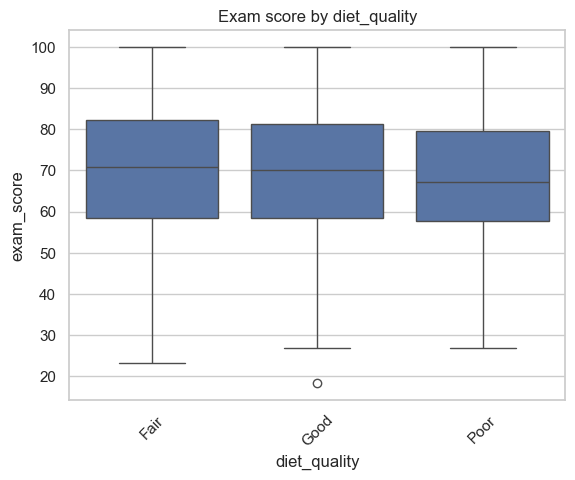

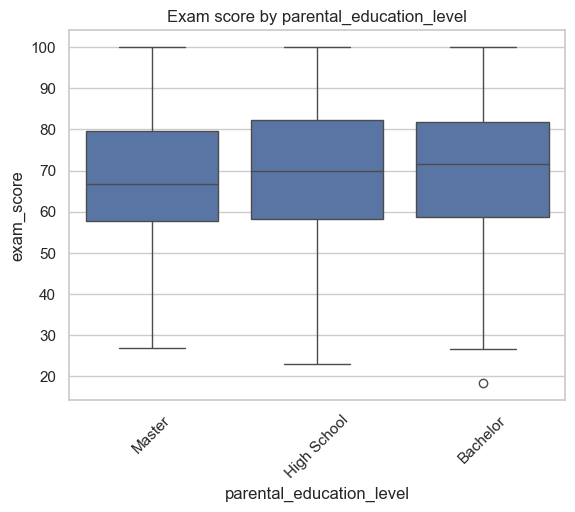

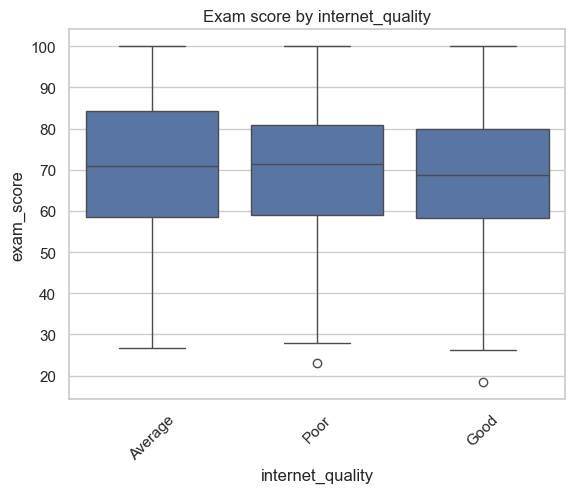

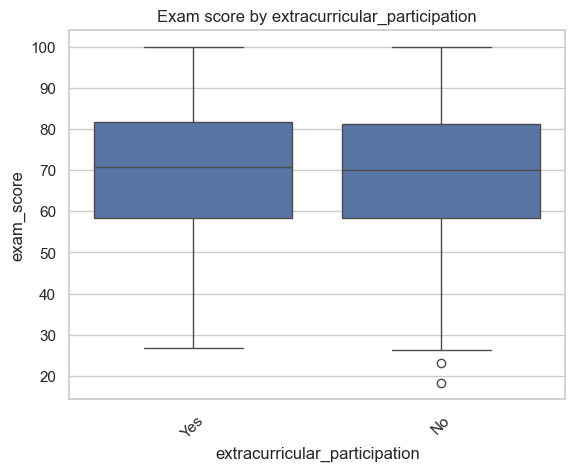

In [12]:
for col in categorical_col:
  sns.boxplot(data=df,x=col,y="exam_score")
  plt.title(f"Exam score by {col}")
  plt.xticks(rotation=45)
  plt.show()

In [13]:
features=['attendance_percentage','mental_health_rating','study_hours_per_day','sleep_hours','part_time_job']

In [14]:
target="exam_score"

In [15]:
df_model= df[features + [target]].copy()


In [16]:
df_model

,attendance_percentage,mental_health_rating,study_hours_per_day,sleep_hours,part_time_job,exam_score
0,85.0,8,0.0,8.0,No,56.2
1,97.3,8,6.9,4.6,No,100.0
2,94.8,1,1.4,8.0,No,34.3
3,71.0,1,1.0,9.2,No,26.8
4,90.9,1,5.0,4.9,No,66.4
...,...,...,...,...,...,...
995,77.0,6,2.6,7.5,No,76.1
996,86.0,6,2.9,6.8,Yes,65.9
997,61.9,9,3.0,6.5,No,64.4
998,100.0,1,5.4,7.6,Yes,69.7


In [17]:
le =LabelEncoder()
df_model["part_time_job"]=le.fit_transform(df_model["part_time_job"])

In [18]:
df_model

,attendance_percentage,mental_health_rating,study_hours_per_day,sleep_hours,part_time_job,exam_score
0,85.0,8,0.0,8.0,0,56.2
1,97.3,8,6.9,4.6,0,100.0
2,94.8,1,1.4,8.0,0,34.3
3,71.0,1,1.0,9.2,0,26.8
4,90.9,1,5.0,4.9,0,66.4
...,...,...,...,...,...,...
995,77.0,6,2.6,7.5,0,76.1
996,86.0,6,2.9,6.8,1,65.9
997,61.9,9,3.0,6.5,0,64.4
998,100.0,1,5.4,7.6,1,69.7


In [19]:
X = df_model[features]

In [20]:
y = df_model[target]

In [21]:
X_train ,X_test ,y_train ,y_test = train_test_split(X,y,test_size=0.2)

In [22]:
len(y_test)

182

In [23]:
len(y_train)

727

In [24]:
models={
  "LinearRegression":{
    "model":LinearRegression(),
    "params":{}
  },
  "DecisionTree" : {
    "model":DecisionTreeRegressor(),
    "params":{"max_depth":[3,5,10],"min_samples_split":[2,5]}
  },
  "RandomForest":{
    "model":RandomForestRegressor(),
    "params":{"n_estimators":[50,100],"max_depth":[5,10]}
  }
}

In [25]:
best_models =[]

In [26]:
for name,config in models.items():
  print(f"Training {name}")
  grid =GridSearchCV(config["model"],config["params"],cv=5,scoring="neg_mean_squared_error")
  grid.fit(X_train,y_train)

  y_pred=grid.predict(X_test)
  rmse = np.sqrt(mean_squared_error(y_test,y_pred))
  r2=r2_score(y_test,y_pred)

  best_models.append({
    "model":name,
    "best_params" : grid.best_params_,
    "rmse":rmse,
    "r2":r2
  })


Training LinearRegression
Training DecisionTree
Training RandomForest


In [27]:
best_models

[{'model': 'LinearRegression',
  'best_params': {},
  'rmse': np.float64(6.668599325457947),
  'r2': 0.8361500193259968},
 {'model': 'DecisionTree',
  'best_params': {'max_depth': 5, 'min_samples_split': 5},
  'rmse': np.float64(8.106382133754872),
  'r2': 0.7578796510681975},
 {'model': 'RandomForest',
  'best_params': {'max_depth': 5, 'n_estimators': 100},
  'rmse': np.float64(7.300540312423567),
  'r2': 0.803624568196958}]

In [28]:
results_df = pd.DataFrame(best_models)

In [29]:
results_df.sort_values(by="rmse")

,model,best_params,rmse,r2
0,LinearRegression,{},6.668599,0.836150
2,RandomForest,"{'max_depth': 5, 'n_estimators': 100}",7.300540,0.803625
1,DecisionTree,"{'max_depth': 5, 'min_samples_split': 5}",8.106382,0.757880


In [30]:
import joblib
best_row=results_df.sort_values(by="rmse").iloc[0]

In [31]:
best_row

model          LinearRegression
best_params                  {}
rmse                   6.668599
r2                      0.83615
Name: 0, dtype: object

In [32]:
best_model_name=best_row["model"]

In [33]:
best_model_name

'LinearRegression'

In [34]:
best_model_config=models[best_model_name]

In [35]:
best_model_config

{'model': LinearRegression(), 'params': {}}